# Machine Learning Algorithms — Visual Python Practice

**Prepared by:** Madawi Alshebil  
**Email:** Madawi.alshebil@gmail.com  
**Supervisor:** Dr. Safwan Al-Selwi  
**Email:** saf1.alselwi@gmail.com

This beginner-friendly notebook reproduces the examples and visuals used in the presentation:

1. Linear Regression — house price prediction  
2. Logistic Regression — customer purchase probability  
3. Decision Tree — customer purchase prediction  
4. Random Forest — multiple customer purchase trees  
5. Support Vector Machine — purchase classification using age and income  
6. K-Nearest Neighbors — classification using **K = 3**  
7. Naive Bayes — spam-email classification  
8. K-Means — customer segmentation using age and income  

The notebook is self-contained: the small customer-purchase dataset is included directly in the code, so no separate CSV upload is required.


## Interactive playgrounds

Use these links to explore each algorithm visually:

| Algorithm | Interactive playground |
|---|---|
| Linear Regression | [Ordinary Least Squares Regression — Explained Visually](https://setosa.io/ev/ordinary-least-squares-regression/) |
| Logistic Regression | [Interactive Logistic Regression](https://ml-visualized.com/chapter3/interactive_logistic_regression.html) |
| Decision Tree | [Interactive Decision Tree](https://www.interactive-ml.com/decision-tree.html) |
| Random Forest | [Random Forest JavaScript Demo](https://cs.stanford.edu/~karpathy/svmjs/demo/demoforest.html) |
| Support Vector Machine | [SVM JavaScript Demo](https://cs.stanford.edu/~karpathy/svmjs/demo/) |
| K-Nearest Neighbors | [Lusera KNN Visualizer](https://www.luseratech.com/knn-visual) |
| Naive Bayes | [Interactive Naive Bayes](https://www.interactive-ml.com/naive-bayes.html) |
| K-Means | [Interactive K-Means](https://www.interactive-ml.com/k-means.html) |


## Common setup



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


## Customer-purchase dataset used in the presentation

The same small dataset is used for the Decision Tree, Random Forest, SVM, and K-Means examples.
Missing `Age` and `Income` values are replaced with their rounded means, matching the original assignment.


In [ ]:
customer_data = {
    "CustomerID": list(range(1, 16)),
    "Age": [
        22, 34, np.nan, 45, 23,
        40, 31, 27, 52, 38,
        26, np.nan, 28, 41, 33
    ],
    "Income": [
        30000, 45000, np.nan, 60000, 35000,
        55000, 40000, 48000, 65000, 47000,
        37000, np.nan, 42000, 60000, 49000
    ],
    "Gender": [
        "Male", "Female", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Male", "Female", "Male"
    ],
    "ProductCategory": [
        "Electronics", "Clothing", "Electronics", "Furniture", "Electronics",
        "Appliances", "Furniture", "Clothing", "Appliances", "Clothing",
        "Furniture", "Electronics", "Appliances", "Furniture", "Electronics"
    ],
    "Purchased": [
        "Yes", "No", "Yes", "Yes", "No",
        "Yes", "No", "Yes", "Yes", "No",
        "Yes", "Yes", "No", "Yes", "No"
    ]
}

df = pd.DataFrame(customer_data)

df_clean = df.copy()
df_clean["Age"] = df_clean["Age"].fillna(
    round(df_clean["Age"].mean())
).astype(int)
df_clean["Income"] = df_clean["Income"].fillna(
    round(df_clean["Income"].mean())
).astype(int)

df_encoded = df_clean.copy()
df_encoded["Gender"] = df_encoded["Gender"].map(
    {"Female": 0, "Male": 1}
)
df_encoded["Purchased"] = df_encoded["Purchased"].map(
    {"No": 0, "Yes": 1}
)
df_encoded = pd.get_dummies(
    df_encoded,
    columns=["ProductCategory"],
    dtype=int
)

display(df_clean)


,CustomerID,Age,Income,Gender,ProductCategory,Purchased
0,1,22,30000,Male,Electronics,Yes
1,2,34,45000,Female,Clothing,No
2,3,34,47154,Female,Electronics,Yes
3,4,45,60000,Male,Furniture,Yes
4,5,23,35000,Female,Electronics,No
5,6,40,55000,Male,Appliances,Yes
6,7,31,40000,Female,Furniture,No
7,8,27,48000,Male,Clothing,Yes
8,9,52,65000,Female,Appliances,Yes
9,10,38,47000,Male,Clothing,No


# 1. Linear Regression — House Price Prediction

**Purpose:** Fit a straight line between house size and house price.

**Presentation example:** House size in square metres versus price in thousands of SAR.

**Playground:** [Open Linear Regression visualizer](https://setosa.io/ev/ordinary-least-squares-regression/)


Regression equation: Price = -3.33 + 3.00 × House Size
Estimated price for a 160 m² house: 476.67 thousand SAR


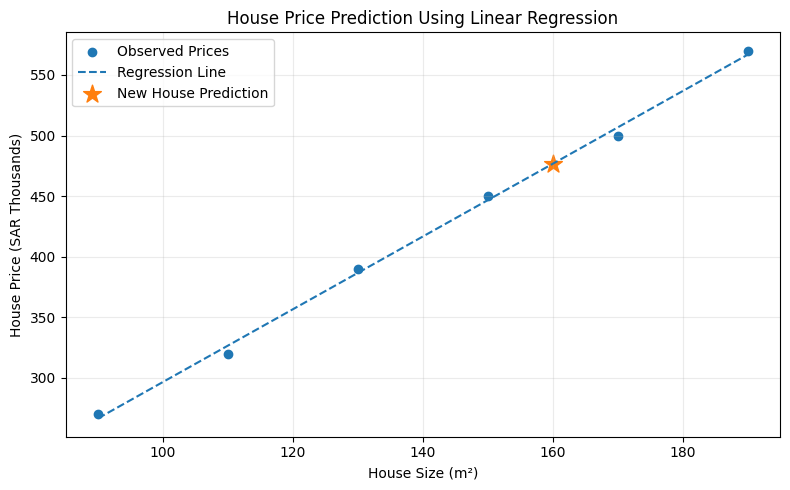

In [ ]:
# Same illustrative values used in the presentation
house_size = np.array([90, 110, 130, 150, 170, 190]).reshape(-1, 1)
house_price = np.array([270, 320, 390, 450, 500, 570])

linear_model = LinearRegression()
linear_model.fit(house_size, house_price)
predicted_prices = linear_model.predict(house_size)

new_house_size = np.array([[160]])
new_price = linear_model.predict(new_house_size)[0]

print(
    f"Regression equation: Price = "
    f"{linear_model.intercept_:.2f} + "
    f"{linear_model.coef_[0]:.2f} × House Size"
)
print(
    f"Estimated price for a 160 m² house: "
    f"{new_price:.2f} thousand SAR"
)

plt.figure(figsize=(8, 5))
plt.scatter(
    house_size[:, 0],
    house_price,
    label="Observed Prices"
)
plt.plot(
    house_size[:, 0],
    predicted_prices,
    linestyle="--",
    label="Regression Line"
)
plt.scatter(
    new_house_size[:, 0],
    [new_price],
    marker="*",
    s=180,
    label="New House Prediction"
)
plt.title("House Price Prediction Using Linear Regression")
plt.xlabel("House Size (m²)")
plt.ylabel("House Price (SAR Thousands)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Try it:** Change one house size or price, rerun the cell, and observe how the fitted line changes.


# 2. Logistic Regression — Customer Purchase Probability

**Purpose:** Convert a customer score into a probability of purchase and classify it using a threshold of 0.5.

The values are illustrative and are used to reproduce the presentation's sigmoid visual.

**Playground:** [Open Logistic Regression visualizer](https://ml-visualized.com/chapter3/interactive_logistic_regression.html)


Example customer score: 1.5
Purchase probability: 84.90%
Predicted class: Purchase


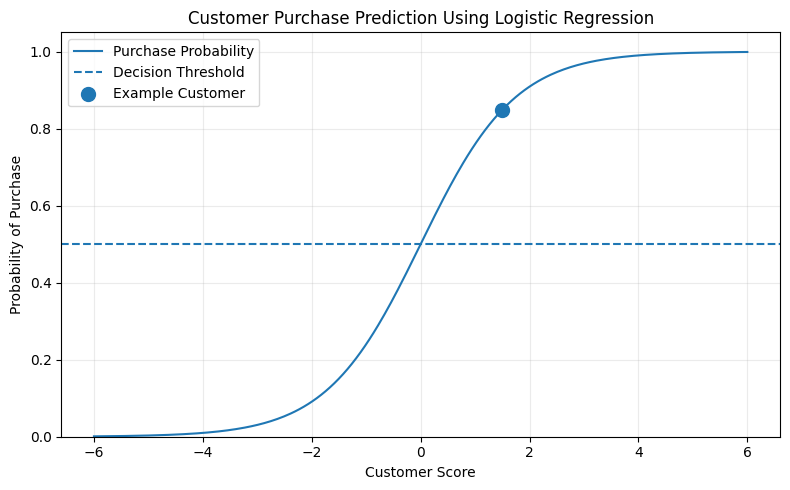

In [ ]:
# Simple illustrative customer scores and purchase labels
training_scores = np.array(
    [-6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6]
).reshape(-1, 1)

# 0 = No Purchase, 1 = Purchase
purchase_labels = np.array(
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
)

logistic_model = LogisticRegression()
logistic_model.fit(training_scores, purchase_labels)

score_grid = np.linspace(-6, 6, 300).reshape(-1, 1)
purchase_probability = logistic_model.predict_proba(score_grid)[:, 1]

example_score = np.array([[1.5]])
example_probability = logistic_model.predict_proba(example_score)[0, 1]
example_prediction = logistic_model.predict(example_score)[0]

print(f"Example customer score: {example_score[0, 0]}")
print(f"Purchase probability: {example_probability:.2%}")
print(
    "Predicted class:",
    "Purchase" if example_prediction == 1 else "No Purchase"
)

plt.figure(figsize=(8, 5))
plt.plot(
    score_grid[:, 0],
    purchase_probability,
    label="Purchase Probability"
)
plt.axhline(
    0.5,
    linestyle="--",
    label="Decision Threshold"
)
plt.scatter(
    example_score[:, 0],
    [example_probability],
    marker="o",
    s=100,
    label="Example Customer"
)
plt.title("Customer Purchase Prediction Using Logistic Regression")
plt.xlabel("Customer Score")
plt.ylabel("Probability of Purchase")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Try it:** Change `example_score` and check whether the predicted class changes at the 0.5 threshold.


# 3. Decision Tree — Customer Purchase Prediction

**Purpose:** Use a simple feature-based rule to classify a customer as Purchase or No Purchase.

The model uses the original unscaled features, matching the Decision Tree shown in the presentation.

**Playground:** [Open Decision Tree visualizer](https://www.interactive-ml.com/decision-tree.html)


Training accuracy: 80.00%
Root split feature: Income
Root split threshold: 47077.0


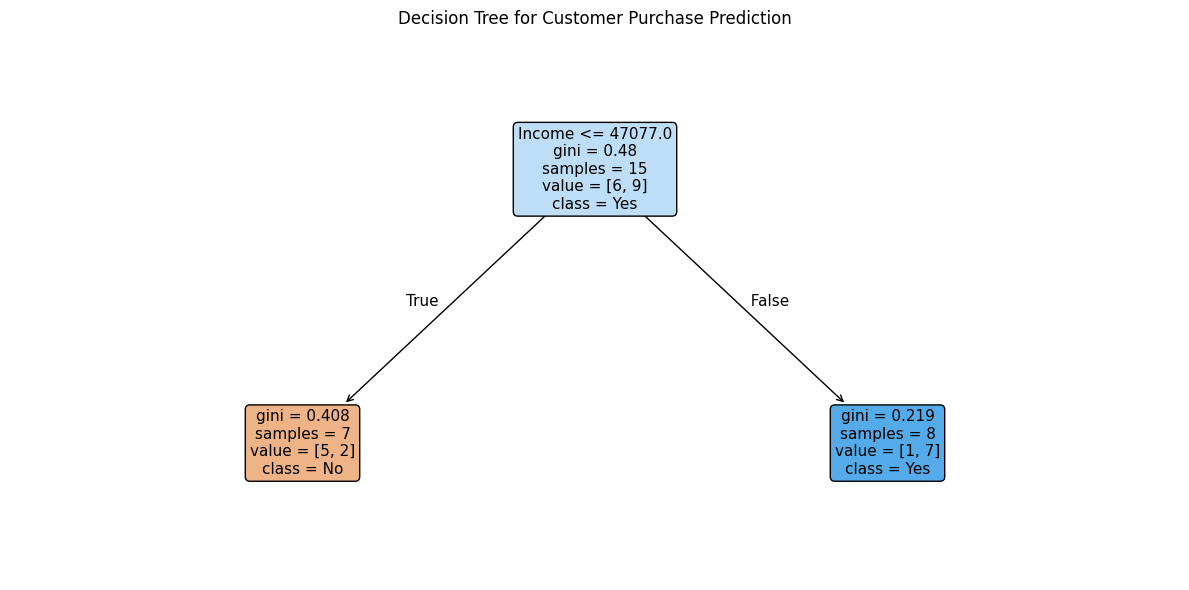

In [ ]:
X_customer = df_encoded.drop(
    columns=["CustomerID", "Purchased"]
)
y_customer = df_encoded["Purchased"]

decision_tree_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)
decision_tree_model.fit(X_customer, y_customer)

training_accuracy = decision_tree_model.score(
    X_customer,
    y_customer
)

print(f"Training accuracy: {training_accuracy:.2%}")
print(
    "Root split feature:",
    X_customer.columns[
        decision_tree_model.tree_.feature[0]
    ]
)
print(
    "Root split threshold:",
    round(decision_tree_model.tree_.threshold[0], 2)
)

plt.figure(figsize=(12, 6))
plot_tree(
    decision_tree_model,
    feature_names=X_customer.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title("Decision Tree for Customer Purchase Prediction")
plt.tight_layout()
plt.show()


**Try it:** Change `max_depth=1` to `max_depth=2` and compare the new tree with the original.


# 4. Random Forest — Customer Purchase Prediction

**Purpose:** Train several Decision Trees using different samples and feature subsets, then combine their predictions.

The plot reproduces the presentation visual by displaying three trees from a five-tree Random Forest.

**Playground:** [Open Random Forest demo](https://cs.stanford.edu/~karpathy/svmjs/demo/demoforest.html)


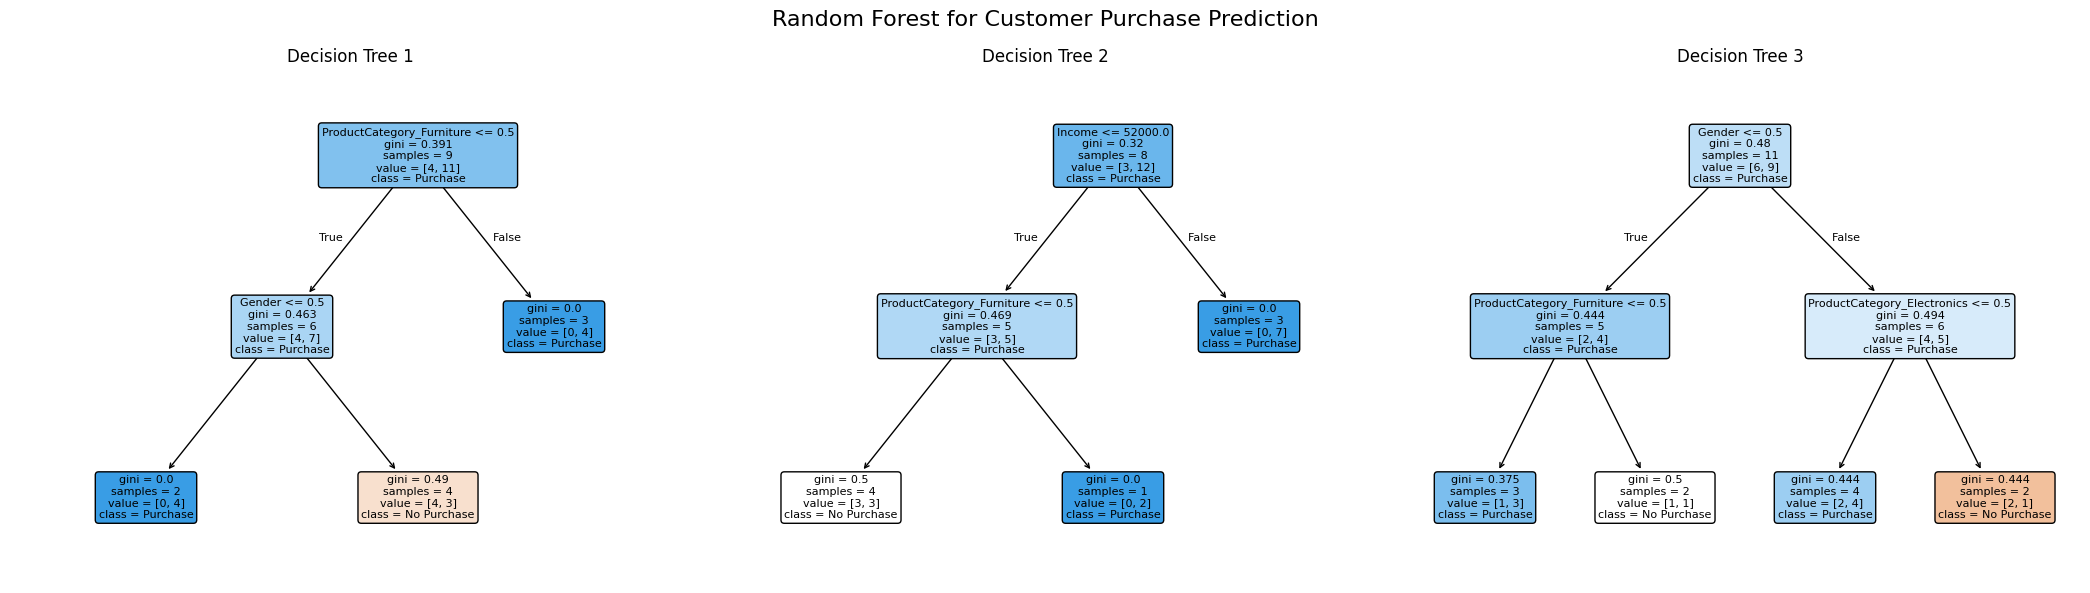

Individual tree votes:
Tree 1: No Purchase
Tree 2: No Purchase
Tree 3: No Purchase
Tree 4: No Purchase
Tree 5: Purchase
Purchase votes: 1
No Purchase votes: 4
Final Random Forest prediction: No Purchase


In [ ]:
random_forest_model = RandomForestClassifier(
    n_estimators=5,
    max_depth=2,
    random_state=42
)
random_forest_model.fit(X_customer, y_customer)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for i, ax in enumerate(axes):
    plot_tree(
        random_forest_model.estimators_[i],
        feature_names=X_customer.columns,
        class_names=["No Purchase", "Purchase"],
        filled=True,
        rounded=True,
        fontsize=8,
        ax=ax
    )
    ax.set_title(f"Decision Tree {i + 1}")

plt.suptitle(
    "Random Forest for Customer Purchase Prediction",
    fontsize=16
)
plt.tight_layout()
plt.show()

# Demonstrate majority voting for the first customer
sample_customer = X_customer.iloc[[0]]
tree_votes = [
    int(tree.predict(sample_customer.to_numpy())[0])
    for tree in random_forest_model.estimators_
]

purchase_votes = sum(tree_votes)
no_purchase_votes = len(tree_votes) - purchase_votes
final_prediction = random_forest_model.predict(
    sample_customer
)[0]

print("Individual tree votes:")
for i, vote in enumerate(tree_votes, start=1):
    label = "Purchase" if vote == 1 else "No Purchase"
    print(f"Tree {i}: {label}")

print(f"Purchase votes: {purchase_votes}")
print(f"No Purchase votes: {no_purchase_votes}")
print(
    "Final Random Forest prediction:",
    "Purchase" if final_prediction == 1 else "No Purchase"
)


**Try it:** Change `n_estimators` or `max_depth` and rerun the model.


# 5. Support Vector Machine — Customer Purchase Prediction

**Purpose:** Use customer age and income to create a decision boundary between Purchase and No Purchase observations.

The outlined observations are the support vectors.

**Playground:** [Open SVM demo](https://cs.stanford.edu/~karpathy/svmjs/demo/)


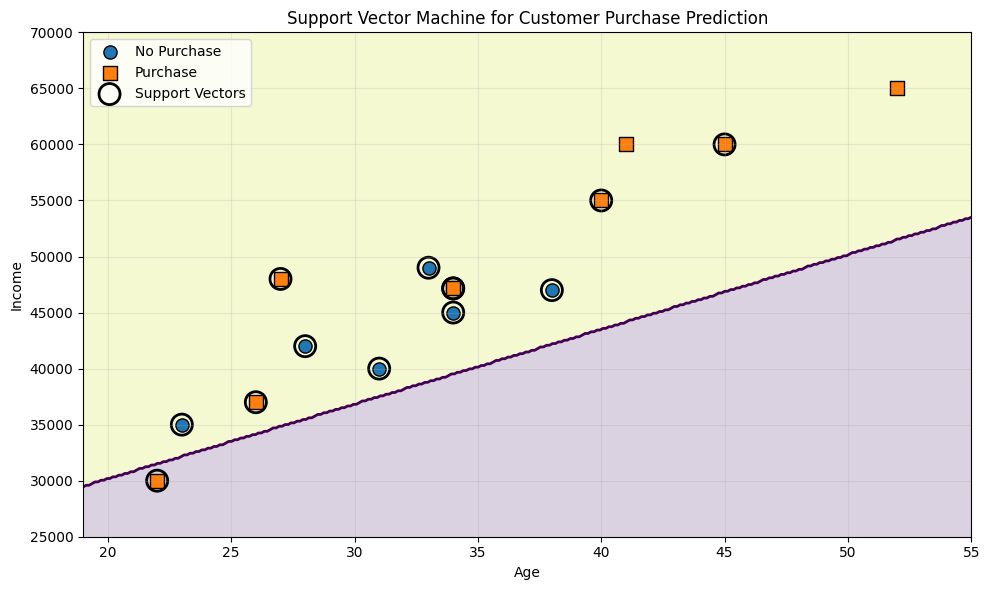

Number of support vectors: 13


In [ ]:
X_svm = df_clean[["Age", "Income"]].copy()
y_svm = df_encoded["Purchased"].astype(int)

svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", C=1)
)
svm_model.fit(X_svm, y_svm)

Z = svm_model.predict(grid).reshape(xx.shape)

age_min = X_svm["Age"].min() - 3
age_max = X_svm["Age"].max() + 3
income_min = X_svm["Income"].min() - 5000
income_max = X_svm["Income"].max() + 5000

xx, yy = np.meshgrid(
    np.linspace(age_min, age_max, 300),
    np.linspace(income_min, income_max, 300)
)

grid = pd.DataFrame({
    "Age": xx.ravel(),
    "Income": yy.ravel()
})


scaler = svm_model.named_steps["standardscaler"]
svc = svm_model.named_steps["svc"]
support_vectors = scaler.inverse_transform(
    svc.support_vectors_
)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.20)
plt.contour(
    xx,
    yy,
    Z,
    levels=[0.5],
    linewidths=2
)

plt.scatter(
    X_svm.loc[y_svm == 0, "Age"],
    X_svm.loc[y_svm == 0, "Income"],
    marker="o",
    s=90,
    edgecolors="black",
    label="No Purchase"
)

plt.scatter(
    X_svm.loc[y_svm == 1, "Age"],
    X_svm.loc[y_svm == 1, "Income"],
    marker="s",
    s=90,
    edgecolors="black",
    label="Purchase"
)

plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=230,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

plt.title("Support Vector Machine for Customer Purchase Prediction")
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(
    f"Number of support vectors: "
    f"{len(support_vectors)}"
)


**Try it:** Replace `kernel="linear"` with `kernel="rbf"` and compare the resulting boundary.


In [ ]:
knn_model = KNeighborsClassifier(
    n_neighbors=3,
    metric="euclidean"
)

knn_model.fit(X_knn, y_knn)

test_point = np.array([[4.7, 4.5]])
prediction = knn_model.predict(test_point)[0]

# 7. Naive Bayes — Spam Email Classification

**Purpose:** Analyze words in an email and compare the probability of Spam versus Not Spam.

This reproduces the presentation example with the email:

> “Congratulations! Claim your free prize now.”

**Playground:** [Open Naive Bayes visualizer](https://www.interactive-ml.com/naive-bayes.html)


Email: Congratulations! Claim your free prize now.
Not Spam Probability: 1.24%
Spam Probability: 98.76%
Final Prediction: Spam


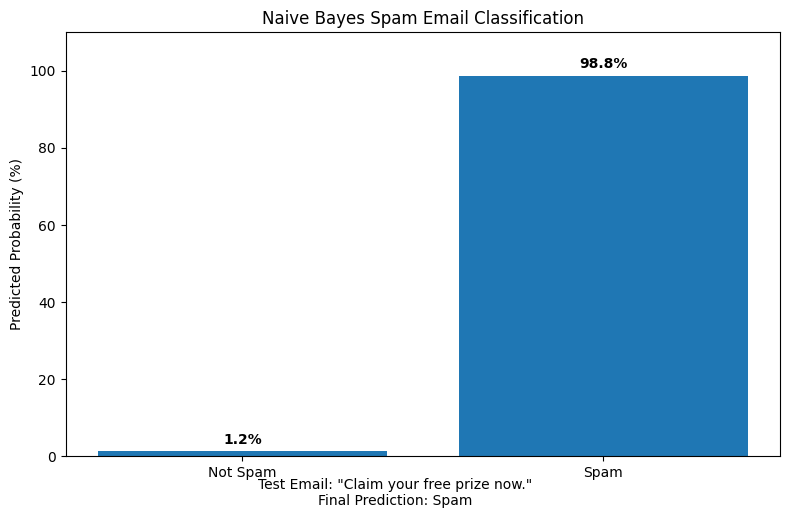

In [ ]:
emails = [
    "Claim your free prize now",
    "Congratulations you won a cash reward",
    "Free offer click here today",
    "Win money and claim your gift",
    "Please attend the project meeting tomorrow",
    "The report has been attached for review",
    "Can we schedule a meeting this afternoon",
    "Your assignment feedback is now available"
]

# 1 = Spam, 0 = Not Spam
email_labels = [1, 1, 1, 1, 0, 0, 0, 0]

naive_bayes_model = make_pipeline(
    CountVectorizer(),
    MultinomialNB()
)
naive_bayes_model.fit(emails, email_labels)

probabilities = naive_bayes_model.predict_proba(
    test_email
)[0]

test_email = [
    "Congratulations! Claim your free prize now."
]

prediction = naive_bayes_model.predict(
    test_email
)[0]

not_spam_probability = probabilities[0] * 100
spam_probability = probabilities[1] * 100

print("Email:", test_email[0])
print(
    f"Not Spam Probability: "
    f"{not_spam_probability:.2f}%"
)
print(
    f"Spam Probability: "
    f"{spam_probability:.2f}%"
)
print(
    "Final Prediction:",
    "Spam" if prediction == 1 else "Not Spam"
)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    ["Not Spam", "Spam"],
    [not_spam_probability, spam_probability]
)

plt.title("Naive Bayes Spam Email Classification")
plt.ylabel("Predicted Probability (%)")
plt.ylim(0, 110)

for bar, value in zip(
    bars,
    [not_spam_probability, spam_probability]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.figtext(
    0.5,
    -0.02,
    'Test Email: "Claim your free prize now."'
    '\nFinal Prediction: Spam',
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()


**Try it:** Replace the test email with a normal work message and compare the probabilities.


# 8. K-Means — Customer Segmentation

**Purpose:** Group customers into three clusters according to similarities in age and income.

K-Means is unsupervised, so it does not use the `Purchased` label.

**Playground:** [Open K-Means visualizer](https://www.interactive-ml.com/k-means.html)


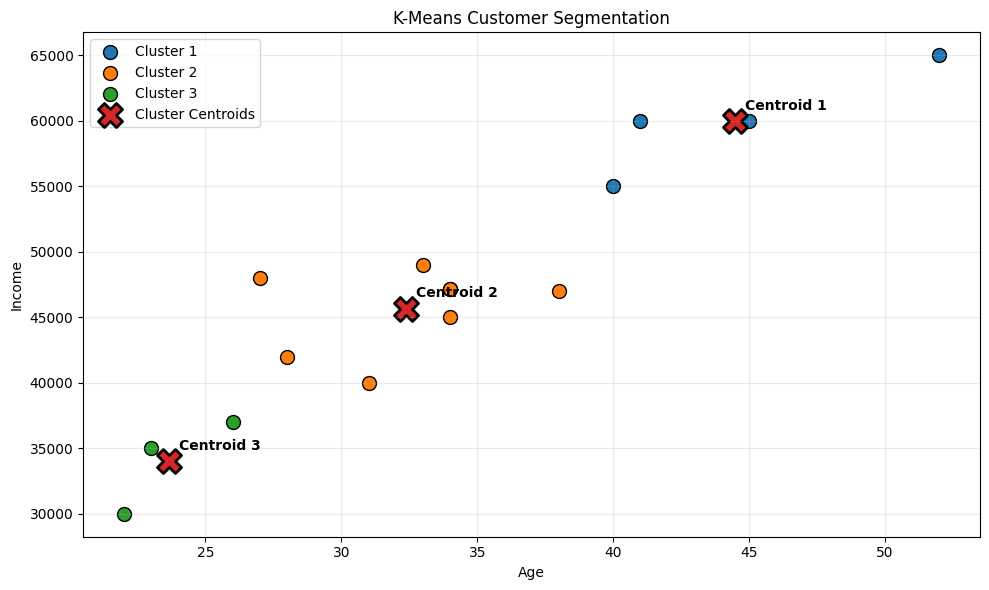

,Customer_Count,Mean_Age,Mean_Income
Cluster,,,
1,4,44.50,60000.0
2,8,32.38,45663.5
3,3,23.67,34000.0


In [ ]:
X_kmeans = df_clean[["Age", "Income"]].copy()

kmeans_scaler = StandardScaler()
X_kmeans_scaled = kmeans_scaler.fit_transform(
    X_kmeans
)

kmeans_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_model.fit_predict(
    X_kmeans_scaled
)

centroids = kmeans_scaler.inverse_transform(
    kmeans_model.cluster_centers_
)

plt.figure(figsize=(10, 6))

for cluster_number in range(3):
    cluster_points = X_kmeans[
        cluster_labels == cluster_number
    ]

    plt.scatter(
        cluster_points["Age"],
        cluster_points["Income"],
        s=100,
        edgecolors="black",
        label=f"Cluster {cluster_number + 1}"
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=300,
    edgecolors="black",
    linewidths=2,
    label="Cluster Centroids"
)

for i, centroid in enumerate(centroids):
    plt.annotate(
        f"Centroid {i + 1}",
        (centroid[0], centroid[1]),
        xytext=(7, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

plt.title("K-Means Customer Segmentation")
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

cluster_summary = (
    X_kmeans.assign(Cluster=cluster_labels + 1)
    .groupby("Cluster")
    .agg(
        Customer_Count=("Age", "size"),
        Mean_Age=("Age", "mean"),
        Mean_Income=("Income", "mean")
    )
    .round(2)
)

display(cluster_summary)


**Try it:** Change `n_clusters=3` to `n_clusters=2` or `n_clusters=4` and compare the groups.


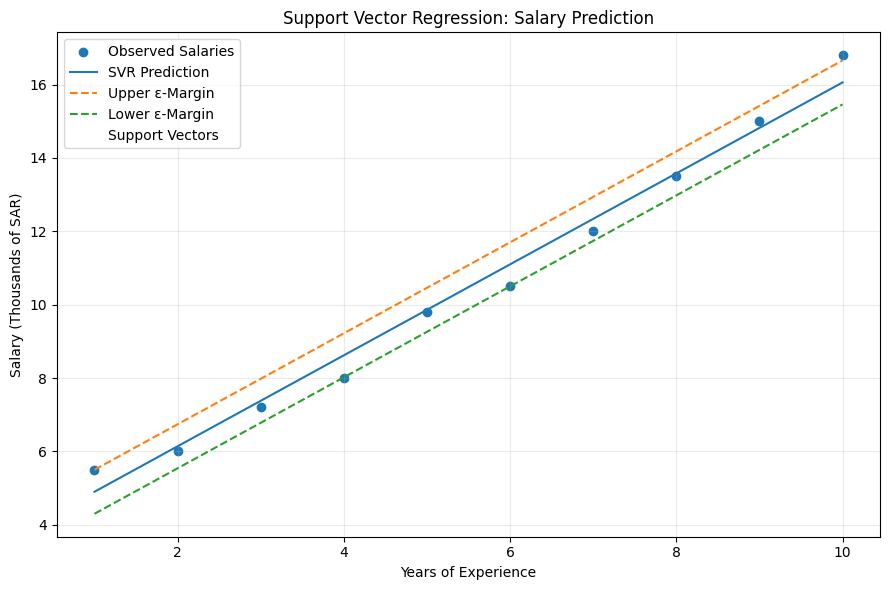

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Years of experience and salary in thousands of SAR
experience = np.array(
    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
).reshape(-1, 1)

salary = np.array(
    [5.5, 6.0, 7.2, 8.0, 9.8,
     10.5, 12.0, 13.5, 15.0, 16.8]
)

epsilon = 0.6

# Create and train the SVR model
svr_model = make_pipeline(
    StandardScaler(),
    SVR(kernel="linear", C=10, epsilon=epsilon)
)

svr_model.fit(experience, salary)

# Generate the regression line
experience_line = np.linspace(1, 10, 200).reshape(-1, 1)
predicted_salary = svr_model.predict(experience_line)

# Find the support vectors
support_indices = svr_model.named_steps["svr"].support_

# Create the graph
plt.figure(figsize=(9, 6))

plt.scatter(
    experience[:, 0],
    salary,
    label="Observed Salaries"
)

plt.plot(
    experience_line[:, 0],
    predicted_salary,
    label="SVR Prediction"
)

plt.plot(
    experience_line[:, 0],
    predicted_salary + epsilon,
    linestyle="--",
    label="Upper ε-Margin"
)

plt.plot(
    experience_line[:, 0],
    predicted_salary - epsilon,
    linestyle="--",
    label="Lower ε-Margin"
)

plt.scatter(
    experience[support_indices, 0],
    salary[support_indices],
    s=180,
    facecolors="none",
    linewidths=2,
    label="Support Vectors"
)

plt.title("Support Vector Regression: Salary Prediction")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (Thousands of SAR)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

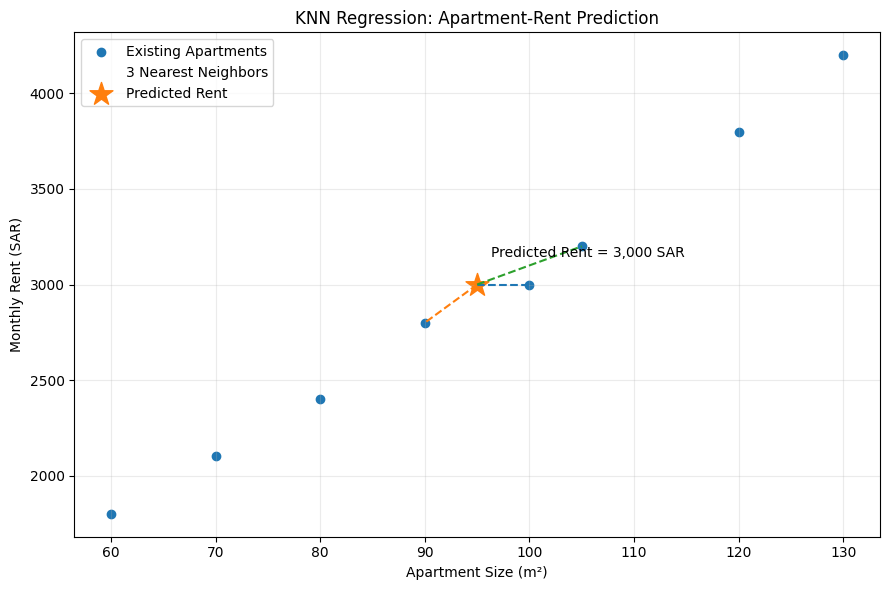

Nearest rents: [3000 2800 3200]
Predicted rent: 3,000 SAR


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors

# Existing apartments: size in m² and monthly rent in SAR
apartment_size = np.array(
    [60, 70, 80, 90, 100, 105, 120, 130]
).reshape(-1, 1)

monthly_rent = np.array(
    [1800, 2100, 2400, 2800, 3000, 3200, 3800, 4200]
)

# New apartment
new_apartment = np.array([[95]])

# Train KNN Regression using K = 3
knn_regressor = KNeighborsRegressor(
    n_neighbors=3,
    weights="uniform"
)

knn_regressor.fit(apartment_size, monthly_rent)

# Predict the new apartment's rent
predicted_rent = knn_regressor.predict(new_apartment)[0]

# Find the three nearest apartments
neighbor_model = NearestNeighbors(n_neighbors=3)
neighbor_model.fit(apartment_size)

distances, neighbor_indices = neighbor_model.kneighbors(
    new_apartment
)

nearest_sizes = apartment_size[neighbor_indices[0], 0]
nearest_rents = monthly_rent[neighbor_indices[0]]

# Create the graph
plt.figure(figsize=(9, 6))

plt.scatter(
    apartment_size[:, 0],
    monthly_rent,
    label="Existing Apartments"
)

plt.scatter(
    nearest_sizes,
    nearest_rents,
    s=180,
    facecolors="none",
    linewidths=2,
    label="3 Nearest Neighbors"
)

plt.scatter(
    new_apartment[0, 0],
    predicted_rent,
    marker="*",
    s=300,
    label="Predicted Rent"
)

# Connect the prediction to its three neighbors
for size, rent in zip(nearest_sizes, nearest_rents):
    plt.plot(
        [new_apartment[0, 0], size],
        [predicted_rent, rent],
        linestyle="--"
    )

plt.annotate(
    f"Predicted Rent = {predicted_rent:,.0f} SAR",
    xy=(new_apartment[0, 0], predicted_rent),
    xytext=(10, 20),
    textcoords="offset points"
)

plt.title("KNN Regression: Apartment-Rent Prediction")
plt.xlabel("Apartment Size (m²)")
plt.ylabel("Monthly Rent (SAR)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Nearest rents:", nearest_rents)
print(f"Predicted rent: {predicted_rent:,.0f} SAR")

# Final practice checklist

After running the notebook, try changing one important setting for every algorithm:

- **Linear Regression:** modify a house price.
- **Logistic Regression:** change the example customer score.
- **Decision Tree:** change `max_depth`.
- **Random Forest:** change `n_estimators`.
- **SVM:** change the kernel.
- **KNN:** change `K` or move the test point.
- **Naive Bayes:** change the email text.
- **K-Means:** change the number of clusters.

The purpose is to observe how each change affects the model or its visual output.
